In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

In [ ]:
import os

file_path = os.path.join('dataset', 'credit_risk_dataset.csv')

try:
    df = pd.read_csv(file_path)
    print("Data uploaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: File not found in path {file_path}. Please check the folder and file name.")

تم تحميل البيانات بنجاح!


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
# Summary statistics for numerical features
print("--- Numerical Summary ---")
display(df.describe())

# Check for missing values
print("\n--- Missing Values Analysis ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Inspect target variable balance
print("\n--- Target Variable Distribution (loan_status) ---")
print(df['loan_status'].value_counts(normalize=True) * 100)

--- Numerical Summary ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



--- Missing Values Analysis ---
person_emp_length     895
loan_int_rate        3116
dtype: int64

--- Target Variable Distribution (loan_status) ---
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


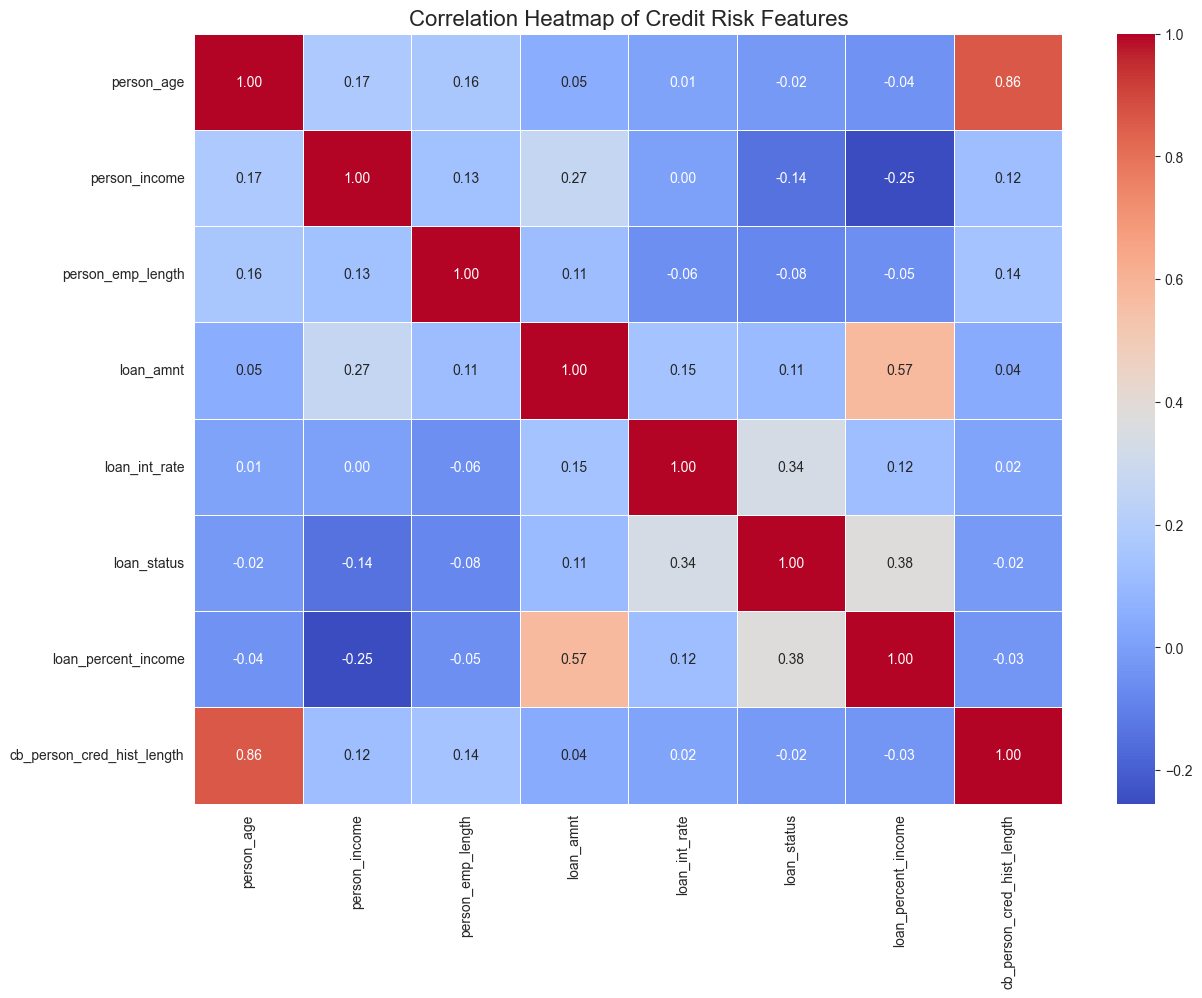

In [9]:
plt.figure(figsize=(14, 10))

corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Credit Risk Features', fontsize=16)
plt.show()

In [4]:
# 1. Handling Outliers (Removing unrealistic values)
# We will keep age < 100 and employment length < 60
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60]

# 2. Handling Missing Values
# We use the median because it's not affected by outliers
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

print(f"Data cleaning complete. Current dataset shape: {df.shape}")

Data cleaning complete. Current dataset shape: (31679, 12)


C:\Temp\ipykernel_27512\3610004406.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
C:\Temp\ipykernel_27512\3610004406.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

In [5]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {list(cat_cols)}")

# Apply One-Hot Encoding
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Show the new columns
print(f"New shape after encoding: {df_final.shape}")
df_final.head()

Categorical columns to encode: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
New shape after encoding: (31679, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


In [6]:
from sklearn.model_selection import train_test_split

# Define Features and Target
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data splitting successful!")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Data splitting successful!
Training set size: 25343
Testing set size: 6336


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the models
lr_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train (Fit) the models
print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training complete!")

Training Logistic Regression...


c:\Users\AnasRah7al\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training complete!


In [8]:
# 3. Make predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# 4. Evaluate Logistic Regression
print("\n--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

# 5. Evaluate Random Forest
print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))


--- Logistic Regression Performance ---
Accuracy: 0.8477
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      4963
           1       0.76      0.44      0.55      1373

    accuracy                           0.85      6336
   macro avg       0.81      0.70      0.73      6336
weighted avg       0.84      0.85      0.83      6336


--- Random Forest Performance ---
Accuracy: 0.9299
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      4963
           1       0.96      0.71      0.81      1373

    accuracy                           0.93      6336
   macro avg       0.94      0.85      0.89      6336
weighted avg       0.93      0.93      0.93      6336



C:\Temp\ipykernel_27512\546672293.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


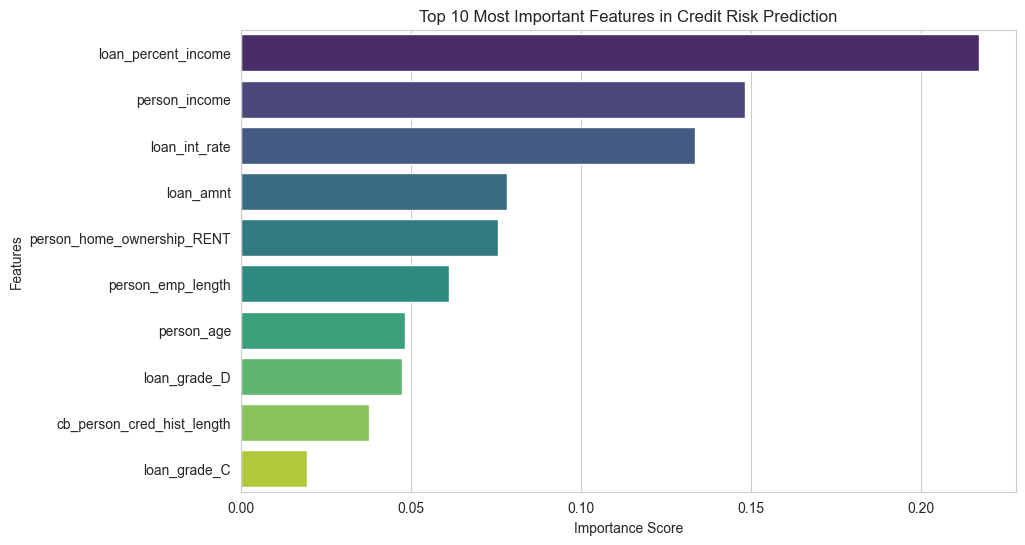

In [9]:
# Extract feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features in Credit Risk Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [10]:
import joblib

# 1. Save the trained Random Forest model
joblib.dump(rf_model, 'credit_risk_model.pkl')

# 2. Save the feature names to ensure consistency later
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Model and Columns saved successfully as .pkl files!")

Model and Columns saved successfully as .pkl files!
